In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets

# metadata
print(covertype.metadata)

# variable information
print(covertype.variables)


{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
covertype = fetch_ucirepo(id=31)

X = covertype.data.features
y = covertype.data.targets

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (581012, 54)
y shape: (581012, 1)


In [5]:
print("Target classes:")
print(y.iloc[:, 0].unique())

print("\nNumber of classes:")
print(y.iloc[:, 0].nunique())

print("\nClass names:")
print("""
1 - Spruce/Fir
2 - Lodgepole Pine
3 - Ponderosa Pine
4 - Cottonwood/Willow
5 - Aspen
6 - Douglas-fir
7 - Krummholz
""")

Target classes:
[5 2 1 7 3 6 4]

Number of classes:
7

Class names:

1 - Spruce/Fir
2 - Lodgepole Pine
3 - Ponderosa Pine
4 - Cottonwood/Willow
5 - Aspen
6 - Douglas-fir
7 - Krummholz



In [6]:
class_counts = y.iloc[:, 0].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

Class distribution:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


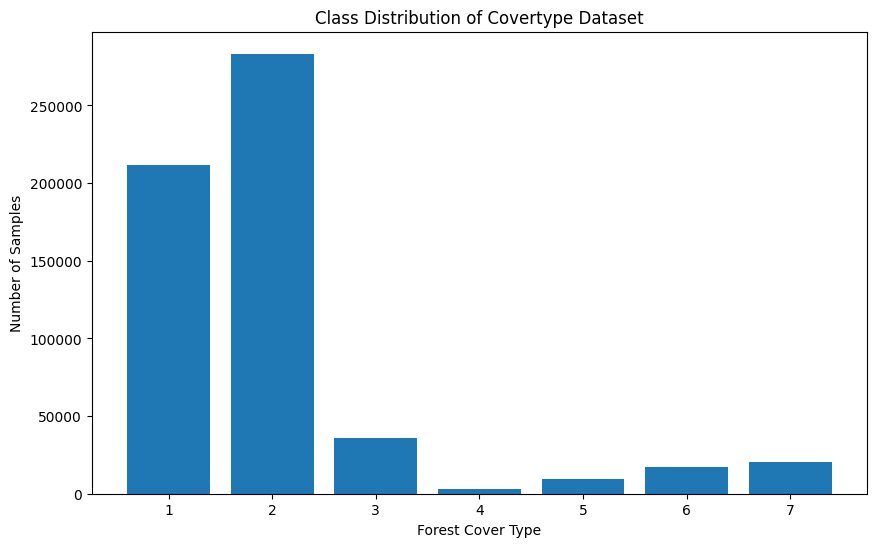

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Covertype Dataset")

plt.xticks(class_counts.index)

plt.show()

In [8]:
max_class = class_counts.max()
min_class = class_counts.min()

imbalance_ratio = max_class / min_class

print("Most frequent class:", max_class)
print("Least frequent class:", min_class)
print("Imbalance ratio:", imbalance_ratio)

Most frequent class: 283301
Least frequent class: 2747
Imbalance ratio: 103.13105205678923


In [9]:
X = covertype.data.features
y = covertype.data.targets

In [10]:
y = y.iloc[:, 0].values

y = y - 1

print("Classes:", np.unique(y))

Classes: [0 1 2 3 4 5 6]


In [11]:
encoder = OneHotEncoder(sparse_output=False)

Y = encoder.fit_transform(y.reshape(-1, 1))

print("Y shape:", Y.shape)

Y shape: (581012, 7)


In [12]:
print("Original classes:")
print(y[:10])

print("\nOne-hot encoded:")
print(Y[:10])

Original classes:
[4 4 1 1 4 1 4 4 4 4]

One-hot encoded:
[[0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]


In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Y shape:", Y.shape)

X shape: (581012, 54)
y shape: (581012,)
Y shape: (581012, 7)


In [14]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
y_temp = np.argmax(Y_temp, axis=1)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [16]:
print("Training:")
print(X_train.shape, Y_train.shape)

print("\nValidation:")
print(X_val.shape, Y_val.shape)

print("\nTesting:")
print(X_test.shape, Y_test.shape)

Training:
(464809, 54) (464809, 7)

Validation:
(58101, 54) (58101, 7)

Testing:
(58102, 54) (58102, 7)


In [17]:
X_train = scaler.fit_transform(X_train)

NameError: name 'scaler' is not defined

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [20]:
print("Training mean:", X_train.mean())
print("Training standard deviation:", X_train.std())

Training mean: -2.2484571054188373e-17
Training standard deviation: 1.0000000000000016


In [21]:
print("Training mean:", X_train.mean())
print("Training standard deviation:", X_train.std())

Training mean: -2.2484571054188373e-17
Training standard deviation: 1.0000000000000016


In [22]:
class_counts_train = np.bincount(train_classes)

print("Class counts:")
print(class_counts_train)

NameError: name 'train_classes' is not defined

In [23]:
train_classes = np.argmax(Y_train, axis=1)

print("First 10 training classes:")
print(train_classes[:10])

First 10 training classes:
[1 1 6 0 4 0 1 1 1 1]


In [24]:
class_counts_train = np.bincount(train_classes)

print("Class counts:")
print(class_counts_train)

Class counts:
[169472 226640  28603   2198   7594  13894  16408]


In [25]:
N = len(Y_train)
K = 7

class_weights = N / (K * class_counts_train)

print("Class weights:")
print(class_weights)

Class weights:
[ 0.39181272  0.29298132  2.32147976 30.20986611  8.74391437  4.77913385
  4.04688479]


In [26]:
for i in range(K):
    print(
        f"Class {i}: "
        f"samples = {class_counts_train[i]}, "
        f"weight = {class_weights[i]:.4f}"
    )

Class 0: samples = 169472, weight = 0.3918
Class 1: samples = 226640, weight = 0.2930
Class 2: samples = 28603, weight = 2.3215
Class 3: samples = 2198, weight = 30.2099
Class 4: samples = 7594, weight = 8.7439
Class 5: samples = 13894, weight = 4.7791
Class 6: samples = 16408, weight = 4.0469


In [27]:
np.random.seed(42)

W1 = np.random.randn(54, 64) * np.sqrt(2 / 54)
b1 = np.zeros((1, 64))

W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
b2 = np.zeros((1, 32))

W3 = np.random.randn(32, 16) * np.sqrt(2 / 32)
b3 = np.zeros((1, 16))

W4 = np.random.randn(16, 7) * np.sqrt(2 / 16)
b4 = np.zeros((1, 7))

In [28]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [29]:
def forward(X):

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)

    Z4 = A3 @ W4 + b4
    Y_hat = softmax(Z4)

    cache = (Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat)

    return Y_hat, cache

In [30]:
Y_hat, cache = forward(X_train[:5])

print("Output shape:", Y_hat.shape)
print("\nPredicted probabilities:")
print(Y_hat)

print("\nProbability sums:")
print(Y_hat.sum(axis=1))

NameError: name 'relu' is not defined

In [32]:
def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [33]:
def forward(X):

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)

    Z4 = A3 @ W4 + b4
    Y_hat = softmax(Z4)

    cache = (Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat)

    return Y_hat, cache

In [34]:
Y_hat, cache = forward(X_train[:5])

print("Output shape:", Y_hat.shape)

print("\nPredicted probabilities:")
print(Y_hat)

print("\nProbability sums:")
print(Y_hat.sum(axis=1))

Output shape: (5, 7)

Predicted probabilities:
[[1.42394448e-01 9.73233487e-02 9.64823103e-02 1.33575213e-01
  9.27991926e-02 1.30053928e-01 3.07371559e-01]
 [1.64085254e-01 1.25844619e-01 2.05537153e-01 1.09621837e-01
  1.09694787e-01 1.52321281e-01 1.32895070e-01]
 [2.73580010e-02 1.98028380e-03 1.69852012e-03 5.85377865e-02
  4.60181852e-04 2.24895756e-03 9.07716269e-01]
 [1.25583571e-01 1.55310747e-01 1.40146564e-01 1.38608486e-01
  1.12742432e-01 1.51057480e-01 1.76550719e-01]
 [1.01835422e-01 1.73128731e-01 1.98398023e-01 2.06385445e-01
  5.46590532e-02 1.14433524e-01 1.51159801e-01]]

Probability sums:
[1. 1. 1. 1. 1.]


In [35]:
def weighted_categorical_cross_entropy(Y, Y_hat, class_weights):

    # Get the class of each sample
    true_classes = np.argmax(Y, axis=1)

    # Get the weight corresponding to each sample's true class
    sample_weights = class_weights[true_classes]

    # Avoid log(0)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)

    # Cross-entropy for each sample
    sample_loss = -np.sum(Y * np.log(Y_hat), axis=1)

    # Apply class weights
    weighted_loss = sample_weights * sample_loss

    # Average over the batch
    return np.mean(weighted_loss)

In [36]:
Y_hat, cache = forward(X_train[:128])

loss = weighted_categorical_cross_entropy(
    Y_train[:128],
    Y_hat,
    class_weights
)

print("Weighted Cross-Entropy Loss:", loss)

Weighted Cross-Entropy Loss: 1.9662297721204463


In [37]:
def backward(X, Y, Y_hat, cache, class_weights):

    Z1, A1, Z2, A2, Z3, A3, Z4, _ = cache

    B = X.shape[0]

    # True class of each sample
    true_classes = np.argmax(Y, axis=1)

    # Weight for each sample
    sample_weights = class_weights[true_classes]

    # Output layer gradient
    dZ4 = (Y_hat - Y) * sample_weights[:, None] / B

    dW4 = A3.T @ dZ4
    db4 = np.sum(dZ4, axis=0, keepdims=True)

    # Hidden layer 3
    dA3 = dZ4 @ W4.T
    dZ3 = dA3 * relu_derivative(Z3)

    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Hidden layer 2
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer 1
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3, dW4, db4

In [38]:
X_batch = X_train[:128]
Y_batch = Y_train[:128]

Y_hat, cache = forward(X_batch)

grads = backward(
    X_batch,
    Y_batch,
    Y_hat,
    cache,
    class_weights
)

print("Backpropagation successful!")

for i, grad in enumerate(grads):
    print(f"Gradient {i+1} shape: {grad.shape}")

Backpropagation successful!
Gradient 1 shape: (54, 64)
Gradient 2 shape: (1, 64)
Gradient 3 shape: (64, 32)
Gradient 4 shape: (1, 32)
Gradient 5 shape: (32, 16)
Gradient 6 shape: (1, 16)
Gradient 7 shape: (16, 7)
Gradient 8 shape: (1, 7)


In [39]:
learning_rate = 0.01
batch_size = 128
epochs = 50

patience = 15

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [40]:
for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))

    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    epoch_loss = 0
    correct = 0
    total = 0

    # Mini-batches
    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # -------------------------
        # Forward propagation
        # -------------------------
        Y_hat, cache = forward(X_batch)

        # -------------------------
        # Calculate loss
        # -------------------------
        loss = weighted_categorical_cross_entropy(
            Y_batch,
            Y_hat,
            class_weights
        )

        epoch_loss += loss * len(X_batch)

        # -------------------------
        # Backpropagation
        # -------------------------
        dW1, db1, dW2, db2, dW3, db3, dW4, db4 = backward(
            X_batch,
            Y_batch,
            Y_hat,
            cache,
            class_weights
        )

        # -------------------------
        # Update parameters
        # -------------------------
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

        W4 -= learning_rate * dW4
        b4 -= learning_rate * db4

        # Training accuracy for this batch
        predictions = np.argmax(Y_hat, axis=1)
        actual = np.argmax(Y_batch, axis=1)

        correct += np.sum(predictions == actual)
        total += len(X_batch)

    # -------------------------
    # Epoch training results
    # -------------------------
    train_loss = epoch_loss / len(X_train)
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    val_predictions, _ = forward(X_val)

    val_loss = weighted_categorical_cross_entropy(
        Y_val,
        val_predictions,
        class_weights
    )

    val_pred_classes = np.argmax(val_predictions, axis=1)
    val_true_classes = np.argmax(Y_val, axis=1)

    val_accuracy = np.mean(
        val_pred_classes == val_true_classes
    )

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # -------------------------
    # Early stopping
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        # Save best weights
        best_W1 = W1.copy()
        best_b1 = b1.copy()

        best_W2 = W2.copy()
        best_b2 = b2.copy()

        best_W3 = W3.copy()
        best_b3 = b3.copy()

        best_W4 = W4.copy()
        best_b4 = b4.copy()

    else:
        patience_counter += 1

        if patience_counter >= patience:

            print("\nEarly stopping triggered!")

            break

Epoch 01/50 | Train Loss: 0.9116 | Train Acc: 0.4950 | Val Loss: 0.7041 | Val Acc: 0.5897
Epoch 02/50 | Train Loss: 0.6553 | Train Acc: 0.6156 | Val Loss: 0.6388 | Val Acc: 0.6167
Epoch 03/50 | Train Loss: 0.5997 | Train Acc: 0.6343 | Val Loss: 0.5888 | Val Acc: 0.6473
Epoch 04/50 | Train Loss: 0.5697 | Train Acc: 0.6492 | Val Loss: 0.5766 | Val Acc: 0.6859
Epoch 05/50 | Train Loss: 0.5455 | Train Acc: 0.6617 | Val Loss: 0.5516 | Val Acc: 0.6759
Epoch 06/50 | Train Loss: 0.5268 | Train Acc: 0.6715 | Val Loss: 0.5191 | Val Acc: 0.6834
Epoch 07/50 | Train Loss: 0.5110 | Train Acc: 0.6797 | Val Loss: 0.5357 | Val Acc: 0.7023
Epoch 08/50 | Train Loss: 0.4973 | Train Acc: 0.6863 | Val Loss: 0.4995 | Val Acc: 0.6701
Epoch 09/50 | Train Loss: 0.4834 | Train Acc: 0.6926 | Val Loss: 0.4872 | Val Acc: 0.7148
Epoch 10/50 | Train Loss: 0.4739 | Train Acc: 0.6991 | Val Loss: 0.4797 | Val Acc: 0.7125
Epoch 11/50 | Train Loss: 0.4633 | Train Acc: 0.7042 | Val Loss: 0.4629 | Val Acc: 0.7101
Epoch 12/5

In [41]:
W1 = best_W1
b1 = best_b1

W2 = best_W2
b2 = best_b2

W3 = best_W3
b3 = best_b3

W4 = best_W4
b4 = best_b4

print("Best model weights restored.")
print("Best validation loss:", best_val_loss)

Best model weights restored.
Best validation loss: 0.3436938967075822


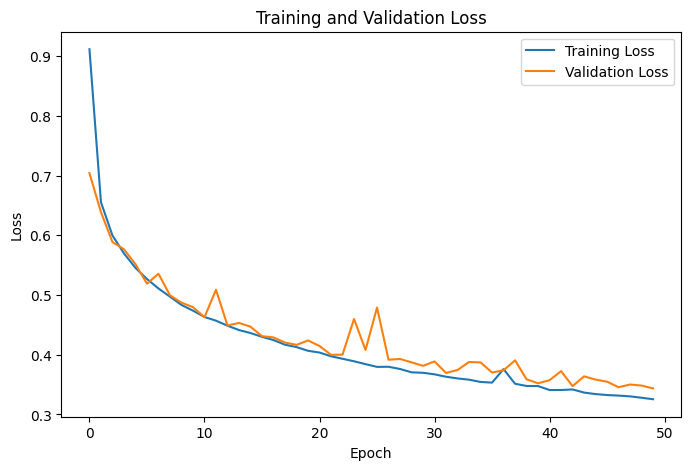

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

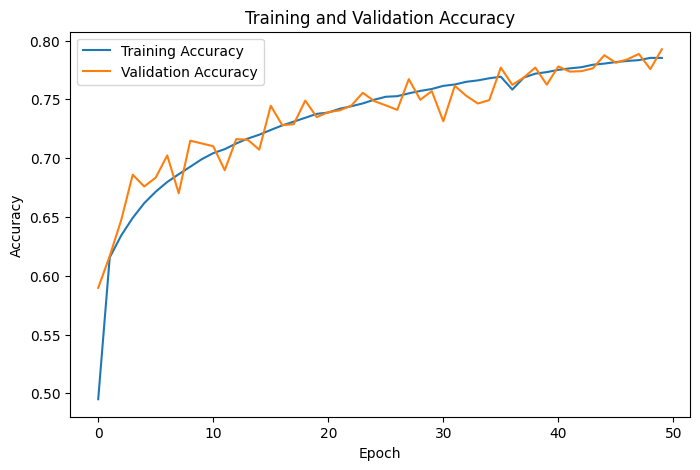

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

In [44]:
test_probabilities, _ = forward(X_test)

test_predictions = np.argmax(test_probabilities, axis=1)
test_actual = np.argmax(Y_test, axis=1)

test_accuracy = accuracy_score(
    test_actual,
    test_predictions
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7895253175450071


In [45]:
precision = precision_score(
    test_actual,
    test_predictions,
    average=None,
    zero_division=0
)

recall = recall_score(
    test_actual,
    test_predictions,
    average=None,
    zero_division=0
)

f1 = f1_score(
    test_actual,
    test_predictions,
    average=None,
    zero_division=0
)

macro_precision = precision_score(
    test_actual,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_actual,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_actual,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Test Accuracy:", test_accuracy)

print("\nMacro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)

print("\nPer-Class Metrics:")

for i in range(7):
    print(
        f"Class {i}: "
        f"Precision={precision[i]:.4f}, "
        f"Recall={recall[i]:.4f}, "
        f"F1={f1[i]:.4f}"
    )

Test Accuracy: 0.7895253175450071

Macro Precision: 0.6783765460259202
Macro Recall: 0.8728384380296037
Macro F1: 0.7408937133832857

Per-Class Metrics:
Class 0: Precision=0.7916, Recall=0.8159, F1=0.8035
Class 1: Precision=0.8664, Recall=0.7414, F1=0.7991
Class 2: Precision=0.7882, Recall=0.8386, F1=0.8126
Class 3: Precision=0.5848, Recall=0.9562, F1=0.7258
Class 4: Precision=0.3164, Recall=0.9684, F1=0.4769
Class 5: Precision=0.5982, Recall=0.8469, F1=0.7011
Class 6: Precision=0.8031, Recall=0.9425, F1=0.8672


In [46]:
print(
    classification_report(
        test_actual,
        test_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.7916    0.8159    0.8035     21184
           1     0.8664    0.7414    0.7991     28331
           2     0.7882    0.8386    0.8126      3576
           3     0.5848    0.9562    0.7258       274
           4     0.3164    0.9684    0.4769       949
           5     0.5982    0.8469    0.7011      1737
           6     0.8031    0.9425    0.8672      2051

    accuracy                         0.7895     58102
   macro avg     0.6784    0.8728    0.7409     58102
weighted avg     0.8138    0.7895    0.7954     58102



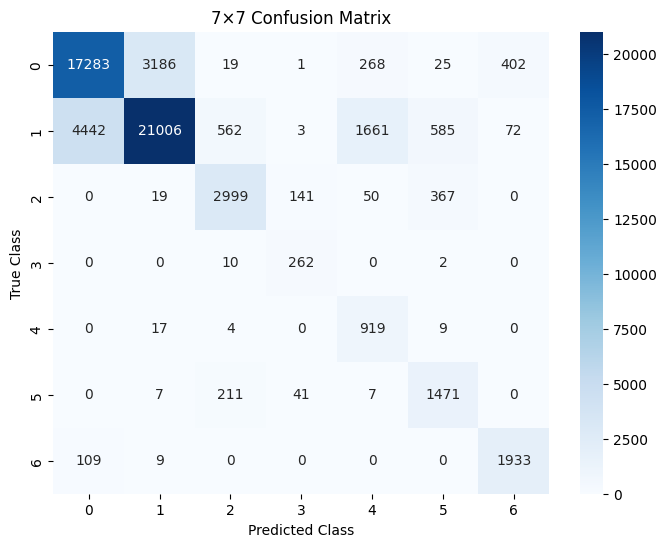

In [47]:
cm = confusion_matrix(
    test_actual,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("7×7 Confusion Matrix")

plt.show()

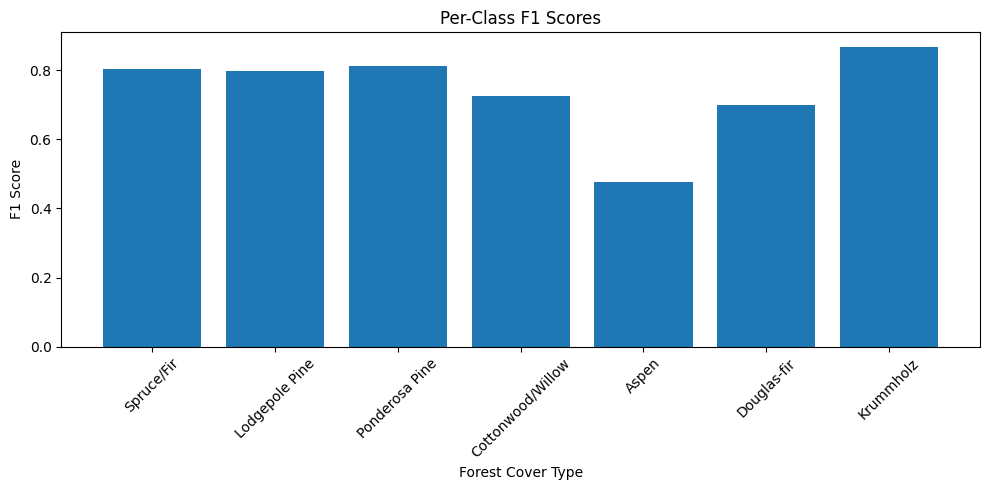

In [48]:
class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

plt.figure(figsize=(10, 5))

plt.bar(class_names, f1)

plt.xlabel("Forest Cover Type")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

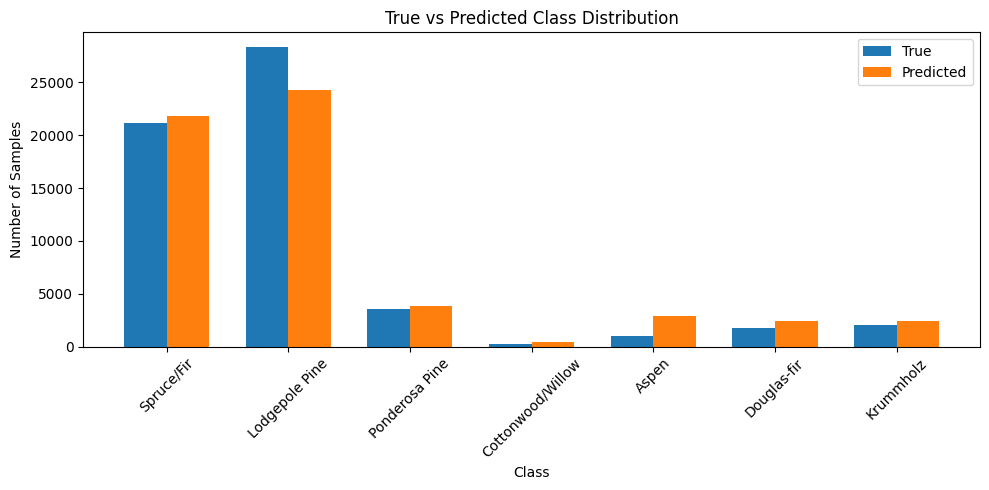

In [49]:
true_counts = np.bincount(test_actual, minlength=7)
pred_counts = np.bincount(test_predictions, minlength=7)

x = np.arange(7)
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    true_counts,
    width,
    label="True"
)

plt.bar(
    x + width/2,
    pred_counts,
    width,
    label="Predicted"
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution")

plt.xticks(x, class_names, rotation=45)

plt.legend()
plt.tight_layout()
plt.show()